PCOS Subtype Analysis (NHANES Cohort)
Researcher: Riya Bhatta
Milestone: Model Optimization and Clustering

In [1]:
import sys
!{sys.executable} -m pip install pyreadstat scikit-learn seaborn pandas


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import pyreadstat
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

print("Environment Ready")

Environment Ready


Data Acquisition : Loading raw files from the folder

In [3]:
files = {'demo': 'DEMO_J.xpt', 'repro': 'RHQ_J.xpt', 'bio': 'BIOPRO_J.xpt', 'hormone': 'SSTST_J.xpt'}
data = {k: pyreadstat.read_xport(v)[0] for k, v in files.items() if os.path.exists(v)}
print(f" {len(data)} files loaded.")

 4 files loaded.


Data Stitching: Merging the files and filtering for women of reproductive age (18-45).

In [4]:
df = pd.merge(data['demo'][['SEQN', 'RIDAGEYR']], data['repro'][['SEQN']], on='SEQN', how='inner')
df = pd.merge(df, data['bio'][['SEQN', 'LBXSGL', 'LBXSTR']], on='SEQN', how='left')
df = pd.merge(df, data['hormone'][['SEQN', 'SSTEST', 'SSTSHBG']], on='SEQN', how='left')

df = df.rename(columns={'SSTEST': 'SSTTSTO'})
df_final = df[(df['RIDAGEYR'] >= 18) & (df['RIDAGEYR'] <= 45)].copy()
print(f" Cohort Size: {len(df_final)}")

 Cohort Size: 1232


EDA : Creating Heatmap

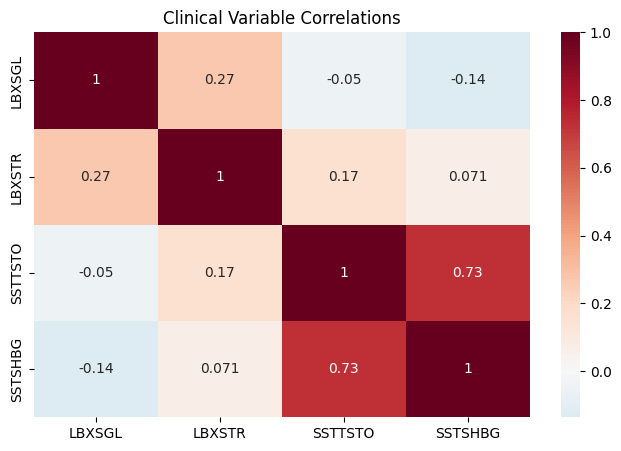

In [5]:
cols_for_ml = ['LBXSGL', 'LBXSTR', 'SSTTSTO', 'SSTSHBG']
plt.figure(figsize=(8, 5))
sns.heatmap(df_final[cols_for_ml].corr(), annot=True, cmap='RdBu_r', center=0)
plt.title('Clinical Variable Correlations')
plt.show()

Data Pre-processing
Handling missing values and scaling the data for Machine Learning.

In [11]:
import numpy as np

# 1. Handle extreme outliers (Capping at 99th percentile)
# This removes the influence of "9999" fill-codes without losing participants
for col in ['LBXSGL', 'LBXSTR', 'SSTTSTO', 'SSTSHBG']:
    upper_limit = df_final[col].quantile(0.99)
    df_final[col] = np.where(df_final[col] > upper_limit, upper_limit, df_final[col])

# 2. KNN Imputation (k=5)
imputer = KNNImputer(n_neighbors=5)
df_final[cols_for_ml] = imputer.fit_transform(df_final[cols_for_ml])

# 3. Scaling for GMM
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_final[cols_for_ml])

print("Data Capped at 99th percentile and Standardized.")

Data Capped at 99th percentile and Standardized.


Optimization (BIC Curve)

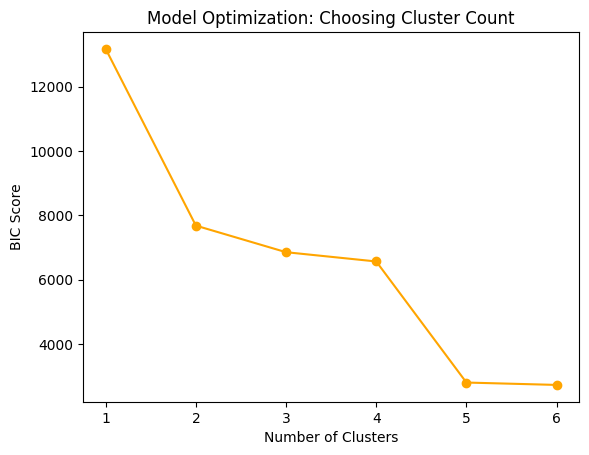

In [12]:
n_components = range(1, 7)
bics = [GaussianMixture(n, random_state=42).fit(X_scaled).bic(X_scaled) for n in n_components]

plt.plot(n_components, bics, marker='o', color='orange')
plt.xlabel('Number of Clusters')
plt.ylabel('BIC Score')
plt.title('Model Optimization: Choosing Cluster Count')
plt.show()

GMM Clustering and Subtypes Profiles

In [13]:
gmm = GaussianMixture(n_components=2, random_state=42)
df_final['Cluster'] = gmm.fit_predict(X_scaled)

print("--- Subtype Clinical Profiles ---")
print(df_final.groupby('Cluster')[cols_for_ml].mean())

--- Subtype Clinical Profiles ---
             LBXSGL      LBXSTR      SSTTSTO     SSTSHBG
Cluster                                                 
0         89.273291  103.358223   117.847160   60.108893
1        103.160081  161.147419  1567.538097  167.915911


Visualization: Scatter Plot

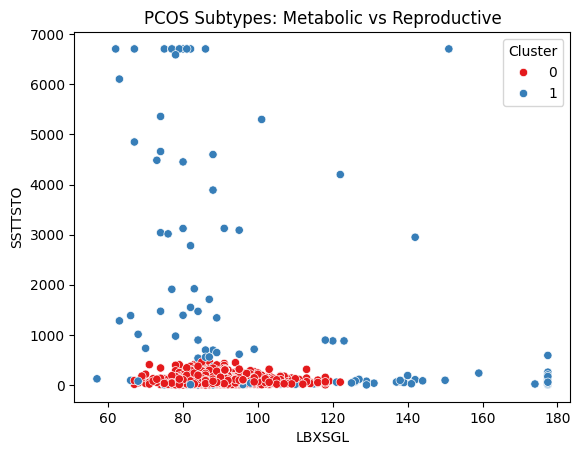

In [17]:
sns.scatterplot(data=df_final, x='LBXSGL', y='SSTTSTO', hue='Cluster', palette='Set1')
plt.title('PCOS Subtypes: Metabolic vs Reproductive')
plt.show()

Export Final Dataset

In [19]:
df_final.to_csv('PCOS_Clustered_Results.csv', index=False)
print("Final Dataset Saved")

Final Dataset Saved
